In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month


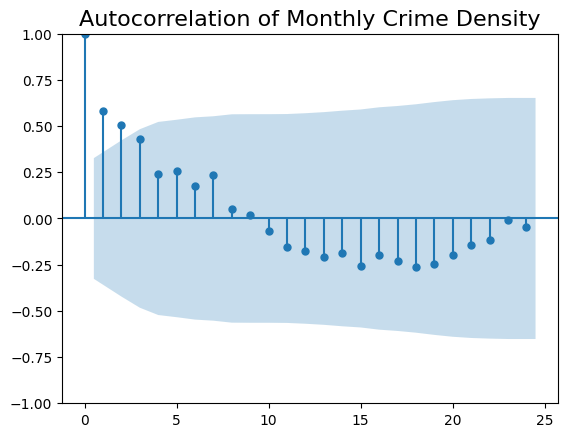

In [2]:
from statsmodels.graphics.tsaplots import plot_acf

# Aggregate by month (sum or mean by date)
monthly_series = df.set_index('Month').resample('ME')['Monthly_Crime_Density'].mean()

# Plot ACF
plot_acf(monthly_series.dropna(), lags=24)
plt.title('Autocorrelation of Monthly Crime Density',fontsize=16)
plt.show()
# ACF plot shows the correlation between crime density values at different time lags since the first 3 lags are outside of the blue shade area, they are statistically significant.
# proving that the crime density isnt random but follows an pattern. First 3 lags are selected for the model.

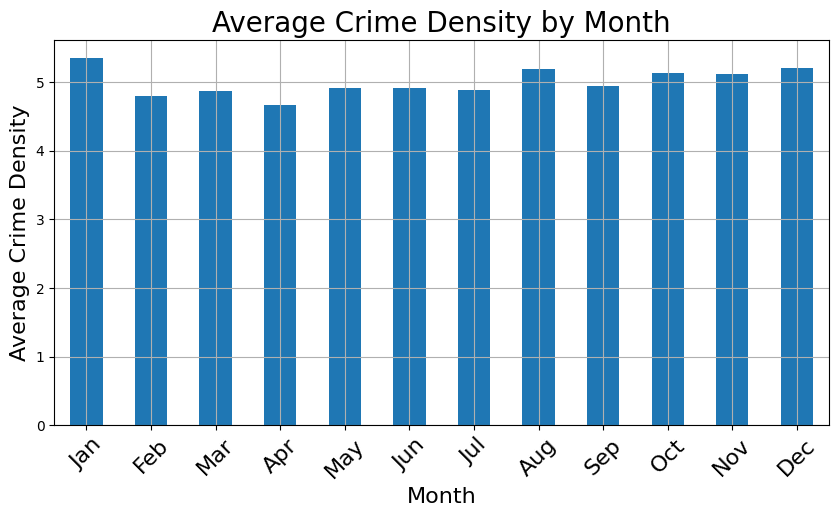

In [4]:
df['Month_Num'] = df['Month'].dt.month

monthly_avg = df.groupby('Month_Num')['Monthly_Crime_Density'].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar')
plt.title('Average Crime Density by Month',fontsize=20)
plt.xlabel('Month',fontsize=16)
plt.ylabel('Average Crime Density',fontsize=16)
plt.grid(True)
plt.xticks(ticks=range(12), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45,fontsize=16)
plt.show()


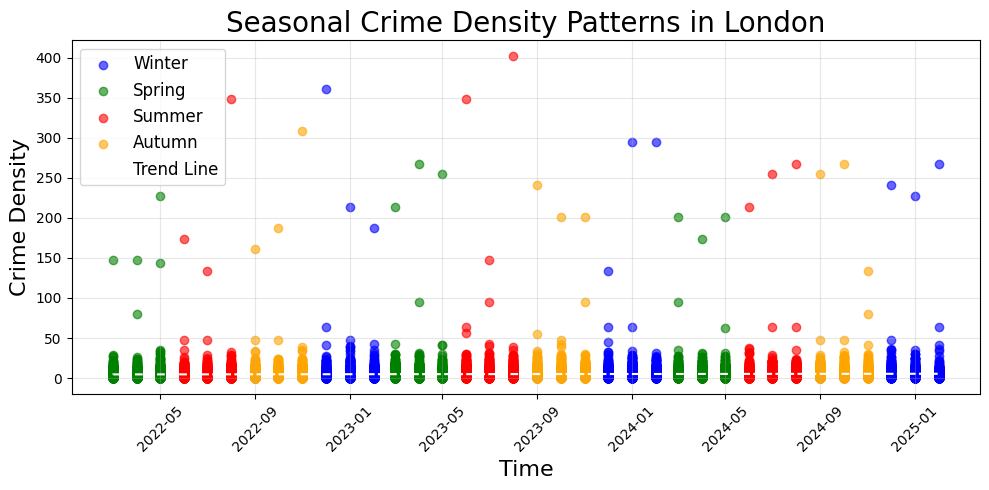


Average Crime Density by Season:
Season
Winter    5.121032
Spring    4.821310
Summer    5.001739
Autumn    5.064292
Name: Monthly_Crime_Density, dtype: float64


In [9]:
# Define seasons for London
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Add season column
df['Season'] = df['Month'].dt.month.apply(get_season)

# Create seasonal analysis plot
plt.figure(figsize=(10, 5))

# Plot each season with different colors
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = ['blue', 'green', 'red', 'orange']

for season, color in zip(seasons, colors):
    season_data = df[df['Season'] == season]
    plt.scatter(season_data['Month'], season_data['Monthly_Crime_Density'], 
                label=season, color=color, alpha=0.6)

# Add trend line
z = np.polyfit(range(len(df)), df['Monthly_Crime_Density'], 1)
p = np.poly1d(z)
plt.plot(df['Month'], p(range(len(df))), 'w--', label='Trend Line')

# Titles and labels
plt.title('Seasonal Crime Density Patterns in London', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Crime Density', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Calculate average crime density by season
seasonal_avg = df.groupby('Season')['Monthly_Crime_Density'].mean().reindex(seasons)
print("\nAverage Crime Density by Season:")
print(seasonal_avg)
#scatter plot showing whether there is seasonal patterns overtime(the answer is no) 